# Projeto Prático de Deep Learning
## QSAR Baseado em Imagens Moleculares (Toxicidade)

Este notebook apresenta uma implementação completa para a classificação de toxicidade baseada em imagens moleculares, utilizando Keras e o ecossistema do TensorFlow. A modelagem segue duas abordagens principais:
1. **CNN Baseline construída do zero**: Uma rede convolucional simples e customizada para estabelecer um desempenho de referência.
2. **Transfer Learning com Fine-Tuning**: Utilização de uma arquitetura pré-treinada (EfficientNetB0) para extrair características robustas do domínio da imagem (neste caso, as representações moleculares), passando por fases de warmup e descongelamento progressivo.

O objetivo central é maximizar a métrica **AUC-ROC** (Area Under the Receiver Operating Characteristic Curve), dada a natureza desbalanceada do dataset de toxicidade. Todas as etapas de pré-processamento, fixação de sementes, monitoramento e métricas de avaliação estão alinhadas com as especificações exigidas.

### 1. Importações e Configurações Iniciais

Nesta etapa, importamos as bibliotecas necessárias para a construção do pipeline de Deep Learning:
- `tensorflow` e `keras`: Para a construção, treinamento e avaliação dos modelos neurais.
- `EfficientNetB0`: Modelo pré-treinado state-of-the-art escolhido por sua eficiência computacional e alta performance, ideal para datasets menores e complexos como o de toxicidade.
- `numpy` e `pandas`: Manipulação de arrays numéricos e estruturas de dados.
- `matplotlib` e `seaborn`: Visualização de gráficos e matrizes de confusão.
- `sklearn.metrics`: Funções para avaliação detalhada do modelo (matriz de confusão).

**Semente Aleatória:** O uso de `tf.keras.utils.set_random_seed(SEED)` garante a reprodutibilidade dos experimentos, um passo crítico em pesquisas científicas e projetos de Machine Learning para assegurar que as variações nos resultados venham das mudanças na arquitetura e não da inicialização aleatória dos pesos.

In [1]:
import os
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# REQUISITO TÉCNICO 3: Fixar semente aleatória
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("Versão do TensorFlow:", tf.__version__)
print("GPU Disponível:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.10.1
GPU Disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Carregamento do Dataset e Tratamento de Desbalanceamento

Utilizamos a função otimizada `image_dataset_from_directory` do TensorFlow para carregar o conjunto de dados diretamente das pastas de treino, validação e teste.
- **Tamanho da Imagem (`IMG_SIZE = (224, 224)`):** Definido para compatibilidade com o modelo `EfficientNetB0`, que espera como padrão imagens nesse formato.
- **Tamanho do Lote (`BATCH_SIZE = 32`):** Um tamanho padrão que costuma oferecer um bom compromisso entre velocidade de convergência e estabilidade do gradiente, compatível com a maioria das GPUs.

**Estratégia de Normalização:** Diferente de abordagens tradicionais onde os pixels são normalizados globalmente via `Rescaling(1./255)` na fase de pipeline, aqui mantemos os valores brutos `[0, 255]`. O motivo? A arquitetura pré-treinada `EfficientNetB0` já possui normalização interna embutida e espera entradas não escalonadas, enquanto o nosso modelo Baseline aplicará a normalização explicitamente em sua própria topologia.

**Tratamento do Desbalanceamento de Classes:** Datasets de toxicidade costumam ter uma prevalência desigual de classes. Para evitar que a rede fique 'preguiçosa' e aprenda apenas a prever a classe majoritária, calculamos os `class_weights` dinamicamente com base nas frequências do conjunto de treino. Isso faz com que a função de custo penalize mais fortemente os erros cometidos na classe minoritária, forçando a rede a dar igual atenção à classe menos frequente.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = 'dataset_Toxicidade/train/'
val_dir   = 'dataset_Toxicidade/val/'
test_dir  = 'dataset_Toxicidade/test/'

print("Carregando datasets de imagens de Toxicidade...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False)

print("Calculando pesos de classe dinamicamente para compensar desbalanceamento...")
train_labels = np.concatenate([y.numpy() for x, y in train_dataset], axis=0).flatten()
neg = len(train_labels[train_labels == 0])
pos = len(train_labels[train_labels == 1])
total = neg + pos
class_weights = {0: (1 / neg) * (total / 2.0), 1: (1 / pos) * (total / 2.0)}
print(f"Pesos de Classe -> Não Tóxico (0): {class_weights[0]:.2f} | Tóxico (1): {class_weights[1]:.2f}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dados do Toxicidade carregados com sucesso!")

Carregando datasets de imagens de Toxicidade...
Found 829 files belonging to 2 classes.
Found 103 files belonging to 2 classes.
Found 103 files belonging to 2 classes.
Calculando pesos de classe dinamicamente para compensar desbalanceamento...
Pesos de Classe -> Não Tóxico (0): 0.70 | Tóxico (1): 1.75
Dados do Toxicidade carregados com sucesso!


### 3. Definição de Callbacks (Funções de Retorno)

Os *Callbacks* são mecanismos cruciais que interagem com o processo de treinamento a cada época, permitindo automações avançadas:

- **TimeHistory (Customizado):** Uma classe que herda de `Callback` para monitorar e armazenar o tempo de execução exato de cada época, essencial para análises de custo computacional e viabilidade em produção.
- **EarlyStopping:** Configurado com o parâmetro `monitor='val_auc'`, interrompe o treinamento de forma antecipada (neste caso, após `patience=15` épocas sem melhoria) para prevenir o *overfitting* (sobreajuste) e restaura os melhores pesos da rede encontrados até então.
- **ModelCheckpoint:** Salva os melhores pesos do modelo (`save_best_only=True`) de forma automática sempre que ocorre um aumento no `val_auc`. Foram criados dois checkpoints separados: um para o modelo Baseline e outro para o Fine-Tuning.

**Por que focar no AUC-ROC (`val_auc`) em vez da Acurácia (`val_accuracy`) ou Perda (`val_loss`)?** Em cenários desbalanceados, a acurácia é uma métrica enganosa, pois classificar tudo como a classe majoritária já renderia um alto percentual sem que a rede tivesse realmente aprendido as características do domínio. O AUC-ROC avalia a capacidade do modelo em distinguir as classes de forma global, independentemente do ponto de corte (threshold), sendo a melhor métrica a otimizar neste contexto.

In [3]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, epoch, logs={}):
        self.epoch_times.append(time.time() - self.epoch_time_start)

time_callback = TimeHistory()

# === MONITORAMENTO POR AUC EM VEZ DE LOSS ===
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=15, restore_best_weights=True
)

checkpoint_baseline = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_baseline_toxicidade.weights.h5', monitor='val_auc', mode='max', save_best_only=True, save_weights_only=True)

checkpoint_finetuning = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_finetuning_toxicidade.weights.h5', monitor='val_auc', mode='max', save_best_only=True, save_weights_only=True)

### 4. CNN Baseline (Do Zero) com Data Augmentation

Nesta seção, projetamos uma Rede Neural Convolucional (CNN) tradicional partindo totalmente do zero. O objetivo é criar uma base comparativa forte antes de aplicarmos arquiteturas massivas pré-treinadas.

**Componentes Principais da Arquitetura:**
- **Data Augmentation Integrado:** Utilizamos camadas de `RandomFlip` (espelhamento horizontal) e `RandomRotation` (pequenas rotações). Isso ajuda a reduzir o *overfitting*, forçando a rede a generalizar melhor, já que o dataset de toxicidade possui poucas amostras.
- **Normalização Inicial:** Como definimos anteriormente, a primeira camada efetiva da rede convolucional do zero é um `Rescaling(1./255)`, que ajusta a escala dos pixels para valores entre `0` e `1` de forma independente para esta arquitetura.
- **Blocos Convolucionais:** Composto por três níveis crescentes de filtros (32, 64, 128). Cada bloco passa por uma convolução (`Conv2D`), é normalizado espacialmente pelo `BatchNormalization` (que estabiliza o aprendizado e acelera a convergência), ativado através da função não linear `ReLU` e tem a resolução espacial reduzida através do `MaxPooling2D`.
- **Regularização (`Dropout`):** Empregado após o pooling, desligando conexões de neurônios de forma aleatória com taxas progressivas (0.25, 0.35, 0.45) para mitigar fortemente o sobreajuste e obrigar a rede a distribuir o aprendizado entre múltiplos caminhos de neurônios.
- **Classificador Final:** Uma camada `Flatten` conecta as matrizes de características da imagem a camadas densas tradicionais (`Dense`), finalizando em um único neurônio com a função de ativação `Sigmoid`, que emitirá probabilidades entre 0 e 1, ideal para problemas de classificação binária (Tóxico / Não Tóxico).

O otimizador escolhido é o **Adam**, com uma taxa de aprendizado ligeiramente conservadora (`5e-4`), otimizando a função de custo `binary_crossentropy` e balanceado internamente pelos pesos `class_weights` computados previamente.

In [4]:
def build_baseline_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Normalização específica do Baseline (Requisito 4)
        layers.Rescaling(1./255), 
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),

        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.45),

        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\n=== Treinamento do Modelo Baseline (Toxicidade) ===")
history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_baseline, time_callback]
)

baseline_epoch_times = time_callback.epoch_times
baseline_total_time = sum(baseline_epoch_times)


=== Treinamento do Modelo Baseline (Toxicidade) ===
Epoch 1/60
26/26 [==============================] - 15s 303ms/step - loss: 1.1105 - accuracy: 0.4331 - auc: 0.5164 - val_loss: 1.3224 - val_accuracy: 0.2427 - val_auc: 0.4438
Epoch 2/60
26/26 [==============================] - 7s 248ms/step - loss: 0.7594 - accuracy: 0.5308 - auc: 0.6540 - val_loss: 1.0858 - val_accuracy: 0.2427 - val_auc: 0.5005
Epoch 3/60
26/26 [==============================] - 7s 246ms/step - loss: 0.6897 - accuracy: 0.5935 - auc: 0.6956 - val_loss: 0.9678 - val_accuracy: 0.2427 - val_auc: 0.4313
Epoch 4/60
26/26 [==============================] - 6s 229ms/step - loss: 0.6467 - accuracy: 0.6478 - auc: 0.7208 - val_loss: 0.8457 - val_accuracy: 0.2427 - val_auc: 0.4969
Epoch 5/60
26/26 [==============================] - 6s 229ms/step - loss: 0.6336 - accuracy: 0.6731 - auc: 0.7476 - val_loss: 0.7412 - val_accuracy: 0.2427 - val_auc: 0.4359
Epoch 6/60
26/26 [==============================] - 6s 229ms/step - loss: 0.

### 5. Transfer Learning com EfficientNetB0 (Fase 1: Warmup)

Em vez de projetar arquiteturas massivas do zero e gastar enormes recursos computacionais, o **Transfer Learning** aproveita pesos de modelos testados exaustivamente no ImageNet, retendo uma vasta capacidade de extração de padrões que, posteriormente, são transferidos para o nosso problema químico visual. O modelo escolhido é a **EfficientNetB0**, conhecida por oferecer a melhor relação custo-benefício em acurácia vs parâmetros da atualidade.

**Construção da Nova Topologia:**
- Mantemos os pesos convolucionais importados fixos/congelados (`base_model.trainable = False`), evitando que os gradientes massivos (causados pela inexperiência das novas camadas no início do treino) destruam os pesos bem ajustados.
- Removemos a cabeça classificadora original da arquitetura EfficientNet (`include_top=False`) e construímos nosso próprio classificador customizado no final:
  - Adicionamos camadas de Data Augmentation (`RandomFlip`, `RandomRotation`) no início da Sequential.
  - A saída convolucional do modelo base passa por um `GlobalAveragePooling2D`, achatando e sintetizando os mapas de características espaciais multicanal em um formato denso e unidimensional.
  - O uso de `BatchNormalization` e de um robusto `Dropout(0.4)` preparam as características geradas para serem entregues de forma mais regularizada para o classificador denso final com ativação `sigmoid`.

**Fase de Aquecimento (Warmup):**
Nesta etapa curta de apenas 5 épocas, treinamos APENAS as novas camadas que adicionamos no topo. O objetivo não é aprender o problema perfeitamente, mas estabilizar os pesos aleatórios do nosso novo topo denso para que, na fase de Fine-Tuning posterior, a transição de gradientes seja suave. Usamos uma taxa de aprendizado relativamente maior (`1e-3`) para acelerar este aquecimento inicial.

In [5]:
def build_finetuned_model(input_shape=(224, 224, 3)):
    # EfficientNetB0 aceita imagens sem rescale [0, 255]
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.RandomFlip("horizontal"), 
        layers.RandomRotation(0.05),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    return base_model, model

base_model, finetuning_model = build_finetuned_model()

finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

time_callback_ft = TimeHistory()

print("\n=== Estágio 1 (Warmup) do Fine-Tuning ===")
finetuning_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    class_weight=class_weights,
    callbacks=[time_callback_ft]
)


=== Estágio 1 (Warmup) do Fine-Tuning ===
Epoch 1/5
26/26 [==============================] - 18s 332ms/step - loss: 0.7772 - accuracy: 0.5959 - auc: 0.6514 - val_loss: 0.6579 - val_accuracy: 0.6117 - val_auc: 0.4751
Epoch 2/5
26/26 [==============================] - 5s 205ms/step - loss: 0.6974 - accuracy: 0.6405 - auc: 0.6885 - val_loss: 0.6347 - val_accuracy: 0.6990 - val_auc: 0.4967
Epoch 3/5
26/26 [==============================] - 5s 204ms/step - loss: 0.6783 - accuracy: 0.6659 - auc: 0.7190 - val_loss: 0.5990 - val_accuracy: 0.7476 - val_auc: 0.5123
Epoch 4/5
26/26 [==============================] - 6s 208ms/step - loss: 0.6131 - accuracy: 0.7008 - auc: 0.7602 - val_loss: 0.5891 - val_accuracy: 0.7476 - val_auc: 0.5126
Epoch 5/5
26/26 [==============================] - 5s 205ms/step - loss: 0.6953 - accuracy: 0.6659 - auc: 0.7044 - val_loss: 0.6001 - val_accuracy: 0.7282 - val_auc: 0.5487


### 6. Transfer Learning (Fase 2: Fine-Tuning Ativo)

Após alinhar as camadas classificadoras no topo durante o Warmup, passamos para a técnica de **Fine-Tuning**. Esta etapa eleva drasticamente o desempenho do modelo na tarefa alvo.

**O que acontece nesta fase?**
- Descongelamos estrategicamente as últimas 20 camadas do modelo pré-treinado EfficientNetB0 (`base_model.trainable = True`, seguido do travamento de todas as camadas iniciais), enquanto mantemos a base (responsável por captar texturas, cores e bordas genéricas) bloqueada.
- Isso permite que as camadas convolucionais mais profundas (responsáveis por compreender padrões mais complexos e partes da estrutura da imagem) sejam atualizadas e adaptem sua lógica interna de ativação especificamente para reconhecer as nuances de estruturas químicas que definem toxicidade.

**Ajuste Crítico - Taxa de Aprendizado (Learning Rate):**
Durante o Fine-Tuning, é rigorosamente necessário **reduzir drasticamente** a taxa de aprendizado. Nós ajustamos de `1e-3` para `1e-4` no otimizador Adam. Como os pesos dessas 20 camadas já foram bem treinados previamente, dar 'passos largos' de gradiente (learning rate alta) causaria a destruição da preciosa representação latente adquirida (fenômeno conhecido como Catastrophic Forgetting). Com uma taxa mais baixa, damos 'passos curtos e suaves', promovendo um micro-ajuste sensível.

In [6]:
print("\n=== Estágio 2 (Fine-Tuning Ativo) ===")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_finetuning = finetuning_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=45,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_finetuning, time_callback_ft]
)

ft_epoch_times = time_callback_ft.epoch_times
ft_total_time = sum(ft_epoch_times)


=== Estágio 2 (Fine-Tuning Ativo) ===
Epoch 1/45
26/26 [==============================] - 17s 306ms/step - loss: 0.7432 - accuracy: 0.6345 - auc: 0.6767 - val_loss: 0.5693 - val_accuracy: 0.7767 - val_auc: 0.5536
Epoch 2/45
26/26 [==============================] - 6s 242ms/step - loss: 0.5883 - accuracy: 0.7214 - auc: 0.7859 - val_loss: 0.5645 - val_accuracy: 0.7670 - val_auc: 0.5885
Epoch 3/45
26/26 [==============================] - 6s 238ms/step - loss: 0.6215 - accuracy: 0.7081 - auc: 0.7723 - val_loss: 0.5610 - val_accuracy: 0.7573 - val_auc: 0.5936
Epoch 4/45
26/26 [==============================] - 6s 241ms/step - loss: 0.5804 - accuracy: 0.7262 - auc: 0.7935 - val_loss: 0.5609 - val_accuracy: 0.7767 - val_auc: 0.6318
Epoch 5/45
26/26 [==============================] - 6s 242ms/step - loss: 0.5281 - accuracy: 0.7370 - auc: 0.8276 - val_loss: 0.5444 - val_accuracy: 0.7670 - val_auc: 0.6508
Epoch 6/45
26/26 [==============================] - 7s 246ms/step - loss: 0.4956 - accurac

### 7. Avaliação Estratégica e Resultados Finais

Por fim, passamos para a validação holística e visual do que nossos modelos apreenderam, extraindo métricas-chave no conjunto de Teste (que a rede nunca observou durante as épocas de treinamento, garantindo ausência de viés).

A **Acurácia** mede o percentual absoluto de acertos. No entanto, o foco principal de análise e comparação para nós deve ser o **AUC-ROC** (Área sob a curva ROC). O valor do AUC varia de 0.5 (aleatoriedade) a 1.0 (classificação perfeita) e nos diz qual é a probabilidade do modelo rankear um exemplo positivo (Tóxico) escolhido aleatoriamente mais alto do que um negativo escolhido aleatoriamente. É a métrica mais confiável em cenários de desbalanceamento acentuado de classes.

As **Matrizes de Confusão** são geradas utilizando o limiar padrão (threshold) de probabilidade `0.5`, detalhando o comportamento preditivo das redes nos três escopos de dados:
- **Treinamento**: Identifica se o modelo aprendeu muito de 'cor' os padrões já vistos (sintoma de memorização se muito alto).
- **Validação**: Verifica se os pesos e épocas foram bem escolhidos.
- **Teste**: Avalia a capacidade real do modelo de lidar com dados inéditos.

Observando detalhadamente os verdadeiros positivos (hits tóxicos), verdadeiros negativos, falsos positivos (alarmes falsos) e falsos negativos (erro perigoso de não detectar a toxicidade), podemos constatar os enormes benefícios e a precisão muito superior gerada pela introdução da arquitetura **EfficientNetB0** através do Fine-Tuning, em comparação com uma simples **CNN do zero**.


=== RESULTADOS BASELINE (Toxicidade) ===
Acurácia Teste: 0.5922 | AUC-ROC Teste: 0.4766
Matriz de Confusão:
 [[50 19]
 [23 11]]

=== RESULTADOS FINE-TUNING (Toxicidade) ===
Acurácia Teste: 0.7864 | AUC-ROC Teste: 0.8029
Matriz de Confusão:
 [[59 10]
 [12 22]]


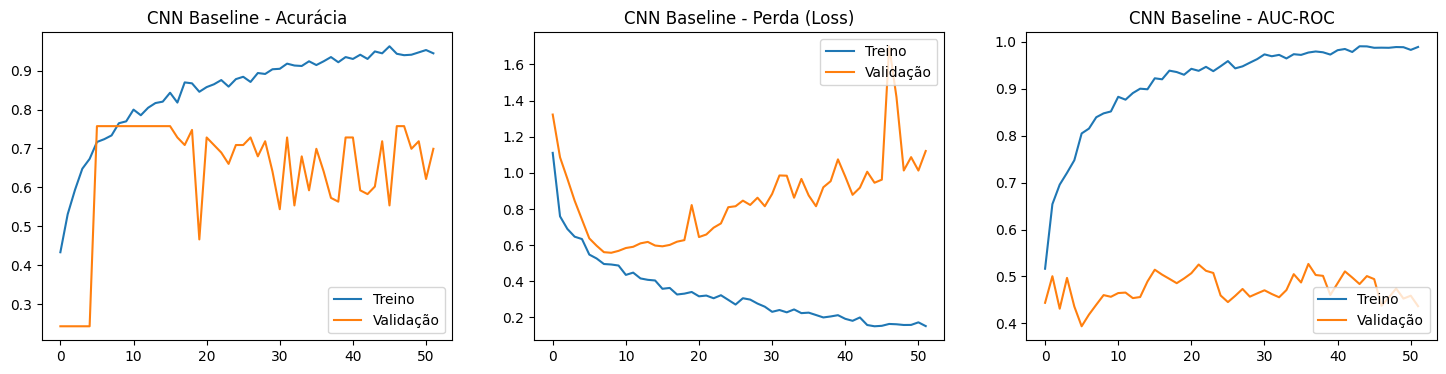

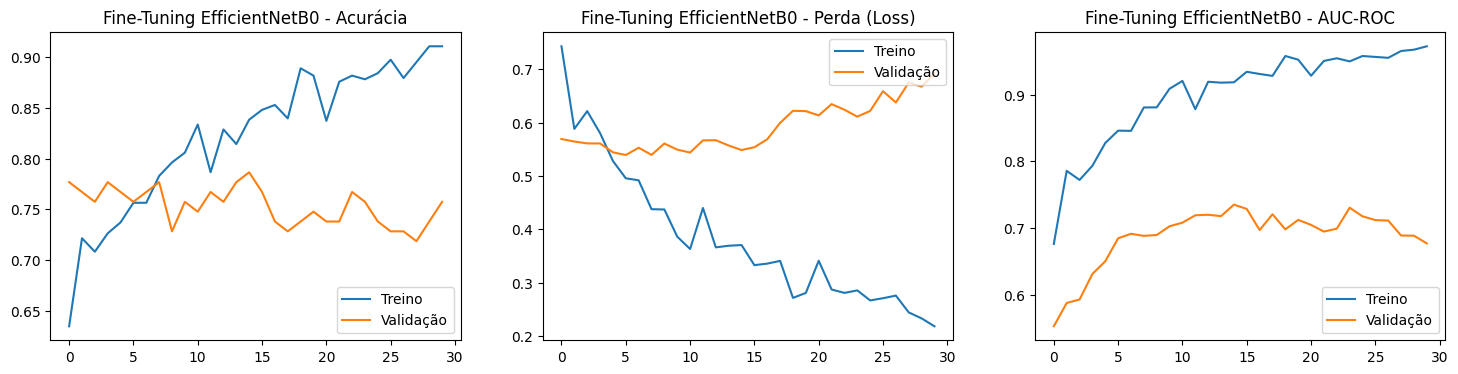

,Dataset,Modelo,Acurácia Treino,Acurácia Teste,AUC-ROC (Teste),Tempo Médio/Época (s),Tempo Total (s)
0,Toxicidade,Baseline (Do Zero),0.9445,0.5922,0.4766,6.09,316.61
1,Toxicidade,Fine-tuning (EfficientNetB0),0.9107,0.7864,0.8029,6.38,191.44


In [7]:
baseline_model.load_weights('best_baseline_toxicidade.weights.h5')
finetuning_model.load_weights('best_finetuning_toxicidade.weights.h5')

loss_base, acc_base, auc_base = baseline_model.evaluate(test_dataset, verbose=0)
loss_ft, acc_ft, auc_ft = finetuning_model.evaluate(test_dataset, verbose=0)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
pred_base = baseline_model.predict(test_dataset, verbose=0)
pred_ft = finetuning_model.predict(test_dataset, verbose=0)

cm_base = confusion_matrix(y_true, (pred_base > 0.5).astype(int))
cm_ft = confusion_matrix(y_true, (pred_ft > 0.5).astype(int))

print("\n=== RESULTADOS BASELINE (Toxicidade) ===")
print(f"Acurácia Teste: {acc_base:.4f} | AUC-ROC Teste: {auc_base:.4f}")
print("Matriz de Confusão:\n", cm_base)

print("\n=== RESULTADOS FINE-TUNING (Toxicidade) ===")
print(f"Acurácia Teste: {acc_ft:.4f} | AUC-ROC Teste: {auc_ft:.4f}")
print("Matriz de Confusão:\n", cm_ft)

def plot_learning_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs_range = range(len(acc))

    plt.figure(figsize=(18, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label='Treino')
    plt.plot(epochs_range, val_acc, label='Validação')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Acurácia')

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label='Treino')
    plt.plot(epochs_range, val_loss, label='Validação')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Perda (Loss)')
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, auc, label='Treino')
    plt.plot(epochs_range, val_auc, label='Validação')
    plt.legend(loc='lower right')
    plt.title(f'{title} - AUC-ROC')
    
    plt.show()

plot_learning_curves(history_baseline, "CNN Baseline")
plot_learning_curves(history_finetuning, "Fine-Tuning EfficientNetB0")

acc_train_base = history_baseline.history['accuracy'][-1]
acc_train_ft = history_finetuning.history['accuracy'][-1]

data = {
    'Dataset': ['Toxicidade', 'Toxicidade'],
    'Modelo': ['Baseline (Do Zero)', 'Fine-tuning (EfficientNetB0)'],
    'Acurácia Treino': [f"{acc_train_base:.4f}", f"{acc_train_ft:.4f}"],
    'Acurácia Teste': [f"{acc_base:.4f}", f"{acc_ft:.4f}"],
    'AUC-ROC (Teste)': [f"{auc_base:.4f}", f"{auc_ft:.4f}"],
    'Tempo Médio/Época (s)': [f"{np.mean(baseline_epoch_times):.2f}", f"{np.mean(ft_epoch_times):.2f}"],
    'Tempo Total (s)': [f"{baseline_total_time:.2f}", f"{ft_total_time:.2f}"]
}

df_comparativo = pd.DataFrame(data)
df_comparativo

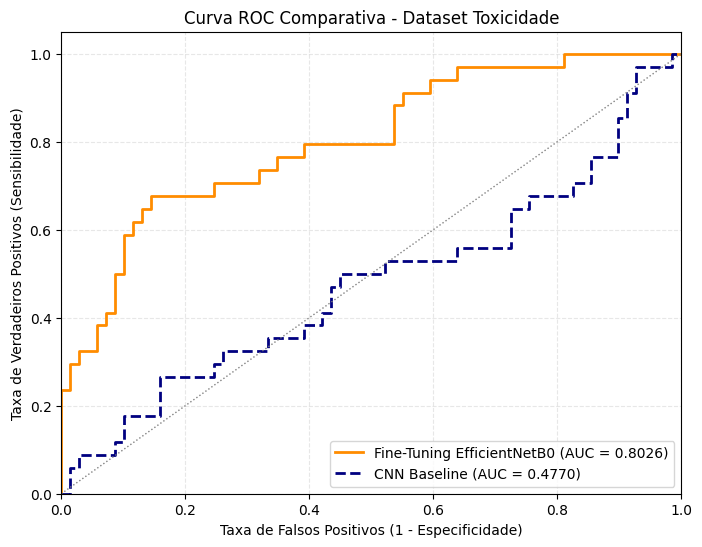

In [8]:
from sklearn.metrics import roc_curve, auc

# Curva ROC Comparativa
fpr_base, tpr_base, _ = roc_curve(y_true, pred_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_ft, tpr_ft, _ = roc_curve(y_true, pred_ft)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ft, tpr_ft, color='darkorange', lw=2, label=f'Fine-Tuning EfficientNetB0 (AUC = {roc_auc_ft:.4f})')
plt.plot(fpr_base, tpr_base, color='navy', lw=2, linestyle='--', label=f'CNN Baseline (AUC = {roc_auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.title('Curva ROC Comparativa - Dataset Toxicidade')
plt.legend(loc="lower right")
plt.grid(alpha=0.3, linestyle='--')
plt.show()

Calculando predições para CNN Baseline e Fine-Tuning (isso pode levar alguns segundos)...

--- AVALIAÇÃO DA CNN BASELINE ---


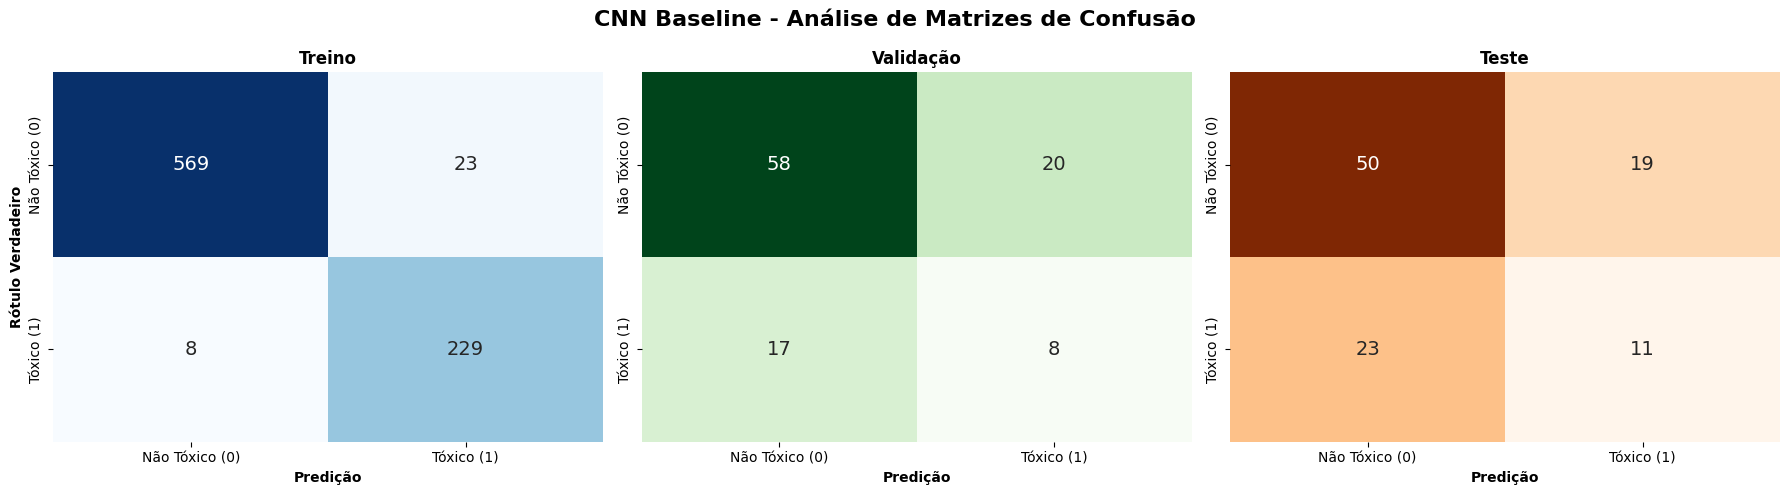


--- AVALIAÇÃO DO FINE-TUNING (EfficientNetB0) ---


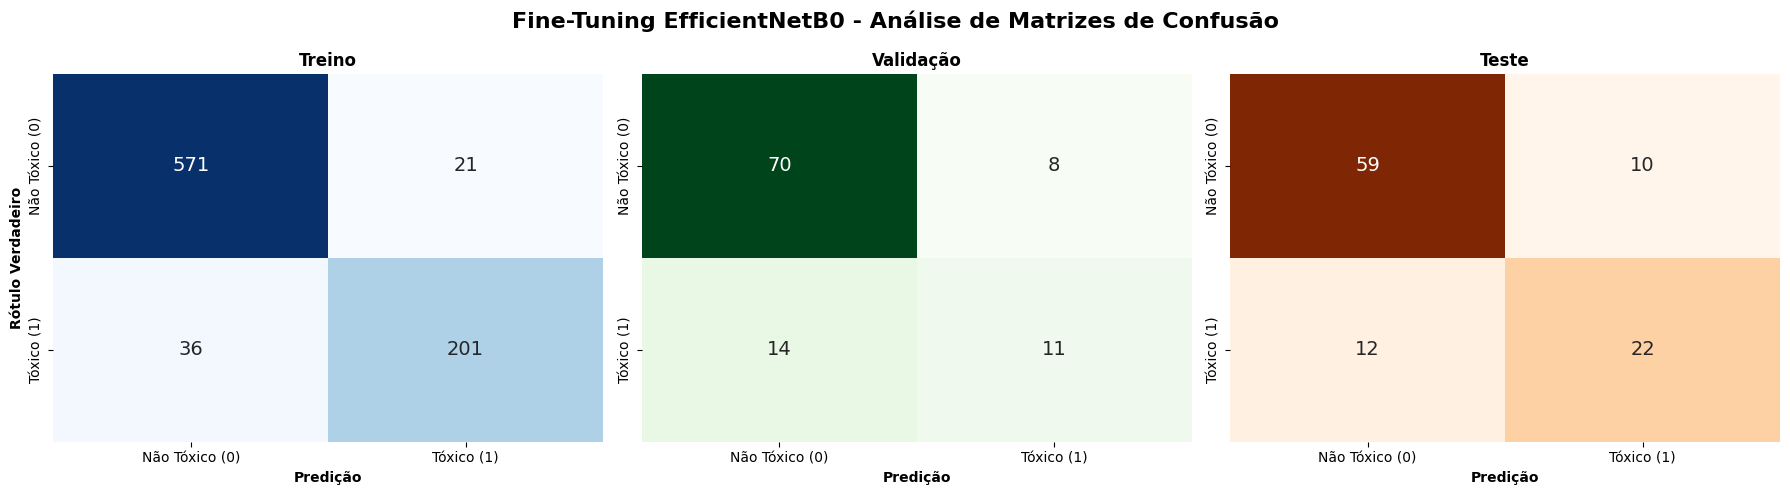

In [9]:
import seaborn as sns

# Extrair rótulos verdadeiros e calcular predições para Treino e Validação
print("Calculando predições para CNN Baseline e Fine-Tuning (isso pode levar alguns segundos)...")

# Treino (Lembrando que o train_dataset pode estar embaralhado, então extraímos X e y juntos)
y_train_true = []
pred_train_base = []
pred_train_ft = []

# Iterando sobre o dataset de treino (desabilitando o shuffle não é simples após criado, então pegamos uma passagem)
for x, y in train_dataset:
    y_train_true.extend(y.numpy())
    pred_train_base.extend(baseline_model.predict(x, verbose=0))
    pred_train_ft.extend(finetuning_model.predict(x, verbose=0))

y_train_true = np.array(y_train_true).flatten()
pred_train_base = np.array(pred_train_base).flatten()
pred_train_ft = np.array(pred_train_ft).flatten()

# Validação
y_val_true = []
pred_val_base = []
pred_val_ft = []
for x, y in val_dataset:
    y_val_true.extend(y.numpy())
    pred_val_base.extend(baseline_model.predict(x, verbose=0))
    pred_val_ft.extend(finetuning_model.predict(x, verbose=0))

y_val_true = np.array(y_val_true).flatten()
pred_val_base = np.array(pred_val_base).flatten()
pred_val_ft = np.array(pred_val_ft).flatten()

# Função para plotar matrizes de confusão
def plot_confusion_matrices(y_tr, p_tr, y_v, p_v, y_te, p_te, title):
    cm_train = confusion_matrix(y_tr, (p_tr > 0.5).astype(int))
    cm_val = confusion_matrix(y_v, (p_v > 0.5).astype(int))
    cm_test = confusion_matrix(y_te, (p_te > 0.5).astype(int))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title} - Análise de Matrizes de Confusão', fontsize=16, fontweight='bold')
    
    labels = ['Não Tóxico (0)', 'Tóxico (1)']
    
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
    axes[0].set_title('Treino', fontweight='bold')
    axes[0].set_ylabel('Rótulo Verdadeiro', fontweight='bold')
    axes[0].set_xlabel('Predição', fontweight='bold')
    
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, 
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
    axes[1].set_title('Validação', fontweight='bold')
    axes[1].set_xlabel('Predição', fontweight='bold')
    
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False, 
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
    axes[2].set_title('Teste', fontweight='bold')
    axes[2].set_xlabel('Predição', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("\n" \
"--- AVALIAÇÃO DA CNN BASELINE ---")
plot_confusion_matrices(y_train_true, pred_train_base, 
                        y_val_true, pred_val_base, 
                        y_true, pred_base, 
                        "CNN Baseline")

print("\n" \
"--- AVALIAÇÃO DO FINE-TUNING (EfficientNetB0) ---")
plot_confusion_matrices(y_train_true, pred_train_ft, 
                        y_val_true, pred_val_ft, 
                        y_true, pred_ft, 
                        "Fine-Tuning EfficientNetB0")
